In [1]:
import pyclesperanto as cle
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from fft_test_helper import gaussian_2d, pad, get_next_smooth

Image size:  (254, 254)


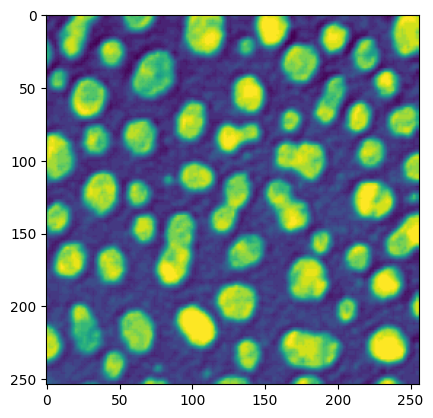

In [3]:
image = io.imread('https://samples.fiji.sc/blobs.png').squeeze()
plt.imshow(image)
image = image[0:254,0:254]
print("Image size: ", image.shape)

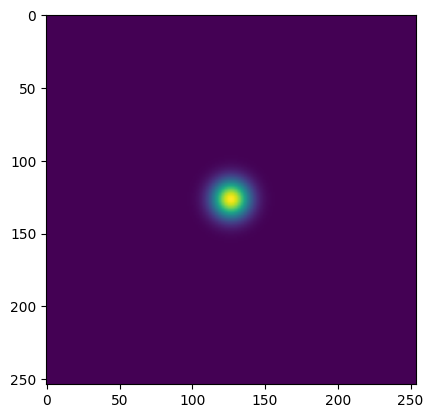

In [4]:
psf = gaussian_2d(image.shape[0],9)
plt.imshow(psf)

In [11]:
padded_size=[max(x,y) for x,y in zip(image.shape, psf.shape)]

# native code only works with 7-smooth sizes
extended_size = get_next_smooth(padded_size)

print(extended_size)

(256, 256)


In [12]:
image = pad(image, extended_size, 'constant')[0]
psf = pad(psf, extended_size, 'constant')[0]

# shift psf so center is at 0,0 (TODO: implement in CLIc)
shifted_psf = np.fft.ifftshift(psf)

image = image.astype(np.float32)
psf = psf.astype(np.float32)

image_gpu = cle.push(image)
psf_gpu = cle.push(psf)
output_gpu = cle.create(image_gpu)
print(type(image_gpu), type(psf_gpu), type(output_gpu))
print(image_gpu.shape, psf_gpu.shape, output_gpu.shape)
blurred_gpu = cle.__experimental__.convolution(image_gpu, psf_gpu , output_gpu, False)
blurred_gpu

<class 'pyclesperanto._pyclesperanto._Array'> <class 'pyclesperanto._pyclesperanto._Array'> <class 'pyclesperanto._pyclesperanto._Array'>
(256, 256) (256, 256) (256, 256)


RuntimeError: Error: Fail to set kernel argument 3. OpenCL error : CL_INVALID_ARG_SIZE (-51).

In [14]:
help(cle.__experimental__.convolution)

Help on built-in function _convolution in module pyclesperanto._pyclesperanto:

_convolution(...) method of builtins.PyCapsule instance
    _convolution(input: pyclesperanto._pyclesperanto._Array, kernel: pyclesperanto._pyclesperanto._Array, output: pyclesperanto._pyclesperanto._Array, correlate: bool) -> pyclesperanto._pyclesperanto._Array

    Apply convolution



In [15]:
import pyclesperanto as cle
import numpy as np

# Initialize GPU
cle.select_device("RTX")  # Change to your available GPU

# Create an example input image
input_np = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]], dtype=np.float32)

# Create a kernel (e.g., 3x3 averaging filter)
kernel_np = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]], dtype=np.float32)

# Convert to GPU arrays
input_gpu = cle.push(input_np)
kernel_gpu = cle.push(kernel_np)

# Create an output array with the same shape as input
output_gpu = cle.create_like(input_gpu)

# Call _convolution (not typically recommended)
output_gpu = cle._pyclesperanto._convolution(input_gpu, kernel_gpu, output_gpu, correlate=False)

# Retrieve result
output_np = cle.pull(output_gpu)
print(output_np)

RuntimeError: Error: Fail to set kernel argument 3. OpenCL error : CL_INVALID_ARG_SIZE (-51).